# Описание эксперимента

Отдел маркетинга предложил новый способ воздействия на клиентские покупки – пуш-уведомления в приложении. До этого основным маркетинговым воздействием было уведомление о новых товарах и скидках с помощью баннера в приложении. Отдел маркетинга предполагает, что новый вид уведомлений более эффективен и с точки зрения конверсии в покупку, и с точки зрения среднего чека.

Чтобы ответить на вопрос, какой способ лучше, с помощью данных, было проведено A/B-тестирование во всех городах России, в которых присутствует ретейлер. Контрольной группе по-прежнему присылали уведомления об акциях и скидках в форме баннера, а тестовой – в форме пуш-уведомления.

Эксперимент продолжался 3 месяца.

Сплит-система: клиенты разбиты на две группы одинакового размера случайным образом.

Были исследованы две таргет-метрики: конверсия из рекламы в покупку и средний чек покупки.

In [1]:
import pandas as pd
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

## Импорт данных

In [2]:
data = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name = 'Данные')
data.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


In [3]:
clients = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name = 'Clients')
clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [4]:
region = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name = 'Region_dict')
region.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


## Проверка таблиц на пропуски данных

In [5]:
data.isnull().sum()

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

In [6]:
print(len(data['id_order']))

37989


**Строки без уникального идентификатора клиента удалим - без этой информации невозможно определить, в какой группе клиент находится, тестовой или контрольной, и к какой торговой точке он прикреплен.**

In [7]:
data = data[~data['id_client'].isnull()]

**Потеря 5,6% данных при 37 тыс. платежей вряд ли критична, поэтому удалим строки без суммы платежа. Подстановка среднего значения или медианы вместо пустых значений может исказить результаты A/B-теста, особенно при сегментации по городам и торговым точкам, поскольку среднее/медиана в разных сегментах могут отличаться.**

In [10]:
data = data[~data['amt_payment'].isnull()]

**Дата оплаты не имеет значения для анализа, поэтому заменим пустые значение датой 01.06.2022.**

In [11]:
data['dtime_pay'] = data['dtime_pay'].fillna(pd.to_datetime('2022-06-01'))

In [12]:
data.isnull().sum()

id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64

In [13]:
clients.isnull().sum()

id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

**Дата показа рекламного объявления не имеет значения для анализа, а вот остальные данные важны, поэтому и здесь заменим пустые значение датой 01.06.2022.**

In [14]:
clients['dtime_ad'] = clients['dtime_ad'].fillna(pd.to_datetime('2022-06-01'))

In [15]:
clients.isnull().sum()

id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
dtype: int64

In [16]:
region.isnull().sum()

id_trading_point    0
city                0
dtype: int64

## Проверка типов данных таблиц

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35845 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     35845 non-null  int64         
 1   id_client    35845 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35845 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.4 MB


**Заменим тип данных в столбце id_client с float на integer:**

In [18]:
data['id_client'] = data['id_client'].astype(int)

In [19]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55605 non-null  datetime64[ns]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.7 MB


In [20]:
region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_trading_point  66 non-null     int64 
 1   city              66 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


## Исследование количества торговых точек в каждом городе

In [21]:
region_gr = region.groupby('city').agg(cnt_piont = ('id_trading_point', 'count')).reset_index()
region_gr.head()

,city,cnt_piont
0,Великий Новгород,1
1,Владимир,1
2,Волгоград,1
3,Дмитров,1
4,Казань,6


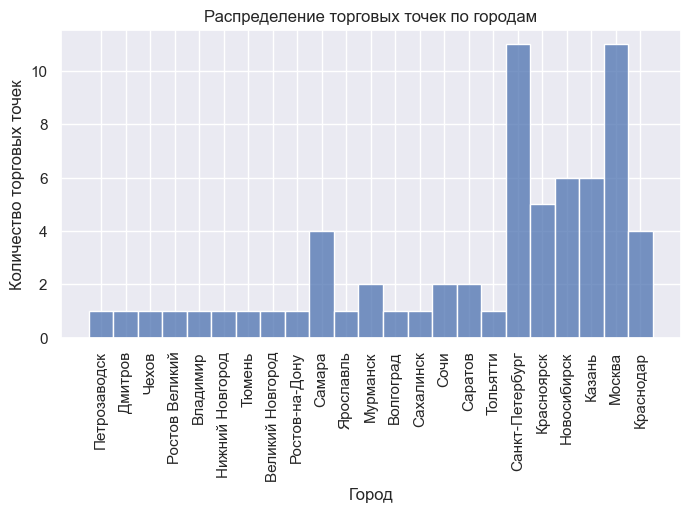

In [22]:
sns.set(rc = {'figure.figsize':(8, 4)})
sns.histplot(data = region, x = "city")
plt.xlabel('Город')
plt.ylabel('Количество торговых точек')
plt.title('Распределение торговых точек по городам')
plt.xticks(rotation = 90)
plt.show()

**В большинстве городов всего одна торговая точка, больше всего торговых точек в Москве и Санкт-Петербурге.**

## Объединение таблиц

**Агрегация таблицы с платежами по клиентам:**

In [23]:
data_gr = data.groupby('id_client').agg(sum_payments = ('amt_payment', 'sum')).reset_index()
data_gr.head()

,id_client,sum_payments
0,178561,3052.0
1,178562,2439.0
2,178563,768.0
3,178565,958.0
4,178566,5474.0


**Соединение таблицы с платежами с клиентской таблицей:**

In [24]:
df = data_gr.merge(clients, on = 'id_client', how = 'right')
df.head()

,id_client,sum_payments,dtime_ad,nflag_test,id_trading_point
0,180844,5349.0,2022-06-08 18:38:41.414,0,212
1,193942,4144.0,2022-06-01 00:00:00.000,0,13
2,226069,NaN,2022-07-11 16:28:38.511,1,54
3,183981,6322.0,2022-06-16 12:23:59.289,1,991
4,322530,NaN,2022-07-08 08:56:08.714,0,1015


In [25]:
print(len(clients['id_client']))
print(len(df['id_client']))

55605
55605


**Заполним нулями суммы покупок тех клиентов, которые их не совершали:**

In [26]:
df['sum_payments'] = df['sum_payments'].fillna(0)
df.head()

,id_client,sum_payments,dtime_ad,nflag_test,id_trading_point
0,180844,5349.0,2022-06-08 18:38:41.414,0,212
1,193942,4144.0,2022-06-01 00:00:00.000,0,13
2,226069,0.0,2022-07-11 16:28:38.511,1,54
3,183981,6322.0,2022-06-16 12:23:59.289,1,991
4,322530,0.0,2022-07-08 08:56:08.714,0,1015


**Добавим к объединенной таблице города, в которых находятся торговые точки:**

In [27]:
df_city = df.merge(region, on = 'id_trading_point', how = 'left')
df_city.head()

,id_client,sum_payments,dtime_ad,nflag_test,id_trading_point,city
0,180844,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск
1,193942,4144.0,2022-06-01 00:00:00.000,0,13,Нижний Новгород
2,226069,0.0,2022-07-11 16:28:38.511,1,54,Мурманск
3,183981,6322.0,2022-06-16 12:23:59.289,1,991,Казань
4,322530,0.0,2022-07-08 08:56:08.714,0,1015,Краснодар


**Добавим столбец с флагом платежа (1 - клиент заплатил, 0 - клиент не заплатил):**

In [28]:
df_city['flag'] = np.where(df_city['sum_payments'] > 0, 1, 0)
df_city.head()

,id_client,sum_payments,dtime_ad,nflag_test,id_trading_point,city,flag
0,180844,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,193942,4144.0,2022-06-01 00:00:00.000,0,13,Нижний Новгород,1
2,226069,0.0,2022-07-11 16:28:38.511,1,54,Мурманск,0
3,183981,6322.0,2022-06-16 12:23:59.289,1,991,Казань,1
4,322530,0.0,2022-07-08 08:56:08.714,0,1015,Краснодар,0


## Статистические вычисления

**Функция, которая будет вычислять значение t-критерия (критерия Стьюдента) и p value для сравнения средних:**

In [29]:
def test_calc(r1, r2, alpha = 0.05):
    s, p = st.ttest_ind(r1, r2)
    print(f'Статистический критерий равен {s}')
    if p < alpha:
        print('Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.')
    else:
        print('Гипотеза о равенстве средних значений не отвергается, средние значения равны.')

**Функция, которая будет рассчитывать значение критерия Манна-Уитни и p value для сравнения распределений:**

In [30]:
def mann_whitney_func(r1, r2, alpha = 0.05):
    U1, p = mannwhitneyu(r1, r2)
    if p < alpha:
        print(f'Принимаем гипотезу H1 -> есть статистически значимая разница между выборками, p value = {p}')
    else:
        print(f'Принимаем гипотезу H0 -> нет статистически значимой разницы между выборками, p value = {p}')

## Чистка неверно заполненных точек

In [31]:
df_trading_point = df_city.groupby(['id_trading_point', 'nflag_test']).agg({'sum_payments':'sum'}).reset_index()
df_trading_point.head()

,id_trading_point,nflag_test,sum_payments
0,1,0,0.0
1,1,1,0.0
2,2,0,34325.0
3,2,1,45188.0
4,4,0,0.0


**Создание списка торговых точек, в которых в тестовой или в контрольной группе не было заплачено ни одного рубля ни одним клиентом:**

In [32]:
list_1 = []

for i in df_trading_point['id_trading_point'].unique():
    if (df_trading_point[df_trading_point['id_trading_point'] == i]['sum_payments'] == 0).any():
        list_1.append(int(i))
print(list_1)    

[1, 4, 7, 26, 46]


**Создание списка торговых точек, в которых пустует или контрольная, или тестовая группа:**

In [33]:
list_2 = []

for i in df_trading_point['id_trading_point'].unique():
    if (df_trading_point[df_trading_point['id_trading_point'] == i]['nflag_test'].nunique() == 1):
        list_2.append(int(i))
print(list_2)    

[228, 603, 739, 800, 810, 866, 1015, 1099]


## Расчет общих результатов A/B-теста

**Уберем из таблицы данные по неверно заполненным торговым точкам:**

In [34]:
df_clean = df_city[~df_city['id_trading_point'].isin(list_1 + list_2)]

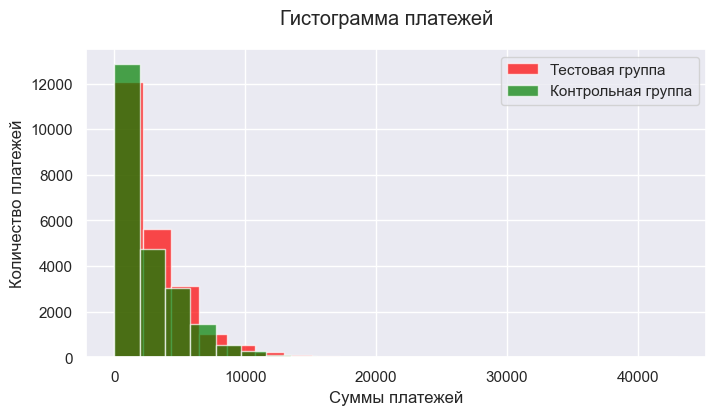

In [35]:
plt.rcParams["figure.figsize"] = (8, 4)
plt.hist(df_clean[df_clean['nflag_test'] == 1]['sum_payments'], color = 'red', alpha = 0.7, bins = 20, label = 'Тестовая группа')
plt.hist(df_clean[df_clean['nflag_test'] == 0]['sum_payments'], color = 'green', alpha = 0.7, bins = 20, label = 'Контрольная группа')
plt.suptitle('Гистограмма платежей')
plt.xlabel('Суммы платежей')
plt.ylabel('Количество платежей')
plt.legend(loc = 'upper right')
plt.show()

**Cравним средние платежи в тестовой и контрольной группах:**

In [36]:
test_calc(df_clean[df_clean['nflag_test'] == 0]['sum_payments'], df_clean[df_clean['nflag_test'] == 1]['sum_payments'], alpha = 0.05)

Статистический критерий равен -9.431025200430836
Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.


**Cравним конверсию в платеж в тестовой и контрольной группах:**

In [37]:
test_calc(df_clean[df_clean['nflag_test'] == 0]['flag'], df_clean[df_clean['nflag_test'] == 1]['flag'], alpha = 0.05)

Статистический критерий равен -9.161599098759664
Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.


**Разница между средними платежами и конверсией в платеж в тестовой и контрольной группах статистически значима, значит применение пуш-уведомлений более эффективно и с точки зрения конверсии в покупку, и с точки зрения среднего чека.**

**Рассчитаем значение критерия Манна Уитни и p value для сравнения распределений:**

In [39]:
mann_whitney_func(df_clean[df_clean['nflag_test'] == 0]['sum_payments'], df_clean[df_clean['nflag_test'] == 1]['sum_payments'], alpha = 0.05)

Принимаем гипотезу H1 -> есть статистически значимая разница между выборками, p value = 6.4266200670011766e-24


**Значение p value очень маленькое, распределения сумм платежей в тестовой и контрольной группах не равны - значит разница в средних значениях платежей не случайна.**

## Сегментация результатов A/B-теста

### Москва

In [40]:
df_clean_Moscow = df_clean[df_clean['city'] == 'Москва']

In [41]:
test_calc(df_clean_Moscow[df_clean_Moscow['nflag_test'] == 0]['sum_payments'], \
          df_clean_Moscow[df_clean_Moscow['nflag_test'] == 1]['sum_payments'], alpha = 0.05)

Статистический критерий равен -7.896238614943354
Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.


In [42]:
test_calc(df_clean_Moscow[df_clean_Moscow['nflag_test'] == 0]['flag'], \
          df_clean_Moscow[df_clean_Moscow['nflag_test'] == 1]['flag'], alpha = 0.05)

Статистический критерий равен -6.427576036124008
Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.


In [43]:
mann_whitney_func(df_clean_Moscow[df_clean_Moscow['nflag_test'] == 0]['sum_payments'], \
                  df_clean_Moscow[df_clean_Moscow['nflag_test'] == 1]['sum_payments'], alpha = 0.05)

Принимаем гипотезу H1 -> есть статистически значимая разница между выборками, p value = 8.651256576787724e-17


**Результаты аналитики по Москве совпадают с общими результатами - разница между средними платежами и конверсией в платеж в тестовой и контрольной группах статистически значима, распределения сумм платежей не равны.**

### Санкт-Петербург

In [44]:
df_clean_SPb = df_clean[df_clean['city'] == 'Санкт-Петербург']

In [45]:
test_calc(df_clean_SPb[df_clean_SPb['nflag_test'] == 0]['sum_payments'], \
          df_clean_SPb[df_clean_SPb['nflag_test'] == 1]['sum_payments'], alpha = 0.05)

Статистический критерий равен -8.759635784179547
Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.


In [46]:
test_calc(df_clean_SPb[df_clean_SPb['nflag_test'] == 0]['flag'], \
          df_clean_SPb[df_clean_SPb['nflag_test'] == 1]['flag'], alpha = 0.05)

Статистический критерий равен -9.352468686561785
Гипотеза о равенстве средних значений отвергается, разница между средними статистически значима.


In [47]:
mann_whitney_func(df_clean_SPb[df_clean_SPb['nflag_test'] == 0]['sum_payments'], \
                  df_clean_SPb[df_clean_SPb['nflag_test'] == 1]['sum_payments'], alpha = 0.05)

Принимаем гипотезу H1 -> есть статистически значимая разница между выборками, p value = 2.0392184217953754e-20


**Результаты аналитики по Санкт-Петербургу также совпадают с общими результатами.**

### Другие города

In [48]:
for i in df_clean['city'].unique():
    if (i != 'Москва') & (i != 'Санкт-Петербург'):
        print(i)
        test_calc(df_clean[(df_clean['city'] == i) & (df_clean['nflag_test'] == 0)]['sum_payments'], \
                  df_clean[(df_clean['city'] == i) & (df_clean['nflag_test'] == 1)]['sum_payments'], alpha = 0.05)
        test_calc(df_clean[(df_clean['city'] == i) & (df_clean['nflag_test'] == 0)]['flag'], \
                  df_clean[(df_clean['city'] == i) & (df_clean['nflag_test'] == 1)]['flag'], alpha = 0.05)
        mann_whitney_func(df_clean[(df_clean['city'] == i) & (df_clean['nflag_test'] == 0)]['sum_payments'], \
                          df_clean[(df_clean['city'] == i) & (df_clean['nflag_test'] == 1)]['sum_payments'], alpha = 0.05)
        print()

Красноярск
Статистический критерий равен -0.12000608689929208
Гипотеза о равенстве средних значений не отвергается, средние значения равны.
Статистический критерий равен 0.27863631219717744
Гипотеза о равенстве средних значений не отвергается, средние значения равны.
Принимаем гипотезу H0 -> нет статистически значимой разницы между выборками, p value = 0.8770469886251647

Нижний Новгород
Статистический критерий равен 1.180381286802843
Гипотеза о равенстве средних значений не отвергается, средние значения равны.
Статистический критерий равен 1.5329710803508039
Гипотеза о равенстве средних значений не отвергается, средние значения равны.
Принимаем гипотезу H0 -> нет статистически значимой разницы между выборками, p value = 0.16861458593517797

Мурманск
Статистический критерий равен -0.06902498862889384
Гипотеза о равенстве средних значений не отвергается, средние значения равны.
Статистический критерий равен -0.8460108060373052
Гипотеза о равенстве средних значений не отвергается, средни

**В большинстве других городов разница между средними платежами и конверсией в платеж в тестовой и контрольной группах статистически незначима, то есть применение пуш-уведомлений не дало результата.  
Результаты аналитики по Самаре совпадают с результатами по Москве и Санкт-Петербургу - разница между средними платежами и конверсией статистически значима, распределения сумм платежей не равны.  
Во Владимире увеличился размер среднего платежа, в Тюмени - конверсия в платеж, значит в этих городах применение пуш-уведомлений эффективно частично.  
В Волгограде применение пуш-уведомлений наоборот привело к уменьшению среднего платежа.  
В Сочи зафиксировано уменьшение конверсии в платеж, что вряд ли связано с изменением вида уведомлений, поскольку статистически значимой разницы между выборками нет.**

## Отчет по A/B-тесту

**Создадим пустой dataframe:**

In [49]:
df_results = pd.DataFrame()

**Запустим цикл по всем городам и торговым точкам:**

In [50]:
city = []
id_trading_point = []

for i in df_clean['city'].unique():
    for j in df_clean['id_trading_point'].unique():
        mask = (df_clean['city'] == i) & (df_clean['id_trading_point'] == j)
        if mask.any():
            city.append(i)
            id_trading_point.append(j)

df_results['city'] = city
df_results['id_trading_point'] = id_trading_point

**Заполним для каждой торговой точки все необходимые поля:**

In [51]:
df_results['count_test'] = df_results['id_trading_point'].map(df_clean[df_clean['nflag_test'] == 1].groupby('id_trading_point').size())
df_results['count_control'] = df_results['id_trading_point'].map(df_clean[df_clean['nflag_test'] == 0].groupby('id_trading_point').size())
df_results['count_all'] = df_results['count_test'] + df_results['count_control']
df_results['percent_count'] = df_results['count_all'] / df_results['count_all'].sum() * 100
df_results['avg_payment_test'] = df_results['id_trading_point'].map(df_clean[df_clean['nflag_test'] == 1].groupby('id_trading_point')['sum_payments'].mean())
df_results['avg_payment_control'] = df_results['id_trading_point'].map(df_clean[df_clean['nflag_test'] == 0].groupby('id_trading_point')['sum_payments'].mean())
df_results['diff'] = df_results['avg_payment_test'] - df_results['avg_payment_control']
df_results['sigma_test'] = df_results['id_trading_point'].map(df_clean[df_clean['nflag_test'] == 1].groupby('id_trading_point')['sum_payments'].std())
df_results['sigma_control'] = df_results['id_trading_point'].map(df_clean[df_clean['nflag_test'] == 0].groupby('id_trading_point')['sum_payments'].std())

In [52]:
for i in df_clean['id_trading_point'].unique():
    s, p = st.ttest_ind(df_clean[(df_clean['id_trading_point'] == i) & (df_clean['nflag_test'] == 0)]['sum_payments'], \
                        df_clean[(df_clean['id_trading_point'] == i) & (df_clean['nflag_test'] == 1)]['sum_payments'])
    mask = df_results['id_trading_point'] == i
    df_results.loc[mask, 'ttest'] = s
    df_results.loc[mask, 'pvalue_ttest'] = p

In [53]:
df_results['label'] = np.where((df_results['diff'] > 0) & (df_results['pvalue_ttest'] < 0.05), 'Positive outcome', \
                               np.where((df_results['diff'] < 0) & (df_results['pvalue_ttest'] < 0.05), 'Negative outcome', \
                                        np.where(df_results['pvalue_ttest'] >= 0.05, 'Neutral outcome', '-')))

In [55]:
df_results.head()

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,label
0,Красноярск,212,593,575,1168,2.547937,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,0.483585,0.628771,Neutral outcome
1,Красноярск,278,535,489,1024,2.233808,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,-1.820268,0.069011,Neutral outcome
2,Красноярск,202,551,565,1116,2.434502,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,-1.155073,0.248308,Neutral outcome
3,Красноярск,444,650,562,1212,2.643921,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,0.876740,0.380802,Neutral outcome
4,Красноярск,277,708,709,1417,3.091119,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,0.981705,0.326413,Neutral outcome


**Выгрузка полученных результатов в Excel:**

In [56]:
%pip install xlsxwriter

Note: you may need to restart the kernel to use updated packages.


In [57]:
writer = pd.ExcelWriter("Results.xlsx", engine = "xlsxwriter")
df_results[df_results['label'] == 'Positive outcome'].to_excel(writer, sheet_name = "Positive outcome")
df_results[df_results['label'] == 'Negative outcome'].to_excel(writer, sheet_name = "Negative outcome")
df_results[df_results['label'] == 'Neutral outcome'].to_excel(writer, sheet_name = "Neutral outcome")
writer.close()